In [27]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)

In [41]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper_bas/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/anti_{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/symmetric_{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/kl_pp")

assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
all_results_df = all_results_df.loc[all_results_df["num_test_observations"] == 50]
all_results_df

solution  \
uuid                                 replication                         
020fe024-d364-42b9-ab4d-bb98f1549173 0            [26.504853109137507]   
                                     1            [29.879991219010936]   
                                     2             [34.51079683893437]   
                                     3             [41.21168988315753]   
                                     4              [39.2247838013642]   
...                                                                ...   
a043c2a2-e52a-434e-a501-0e86987ffb9c 495           [20.27768017237966]   
                                     496          [23.283473590848192]   
                                     497           [25.15791138734521]   
                                     498          [20.063082019758664]   
                                     499           [24.77239261932114]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
020fe024-d364-42b9-ab4d-bb98f1549173 0            0.001808         0.000104   
                                     1            0.000220         0.000086   
                                     2            0.000232         0.000091   
                                     3            0.000228         0.000085   
                                     4            0.000218         0.000090   
...                                                    ...              ...   
a043c2a2-e52a-434e-a501-0e86987ffb9c 495          0.000593         0.000072   
                                     496          0.000584         0.000072   
                                     497          0.000581         0.000080   
                                     498          0.000613         0.000071   
                                     499          0.000547         0.000071   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
020fe024-d364-42b9-ab4d-bb98f1549173 0                  0.000062    0.127450   
                                     1                  0.000055    0.026874   
                                     2                  0.000055    0.025975   
                                     3                  0.000053    0.028253   
                                     4                  0.000055    0.026515   
...                                                          ...         ...   
a043c2a2-e52a-434e-a501-0e86987ffb9c 495                0.000203    0.650378   
                                     496                0.000210    0.709850   
                                     497                0.000204    0.660581   
                                     498                0.000209    0.713435   
                                     499                0.000208    0.653501   

                                                  setup_time  \
uuid                                 replication               
020fe024-d364-42b9-ab4d-bb98f1549173 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   
                                     3                   NaN   
                                     4                   NaN   
...                                                      ...   
a043c2a2-e52a-434e-a501-0e86987ffb9c 495                 NaN   
                                     496                 NaN   
                                     497                 NaN   
                                     498                 NaN   
                                     499                 NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
020fe024-d364-42b9-ab4d-bb98f1549173 0       

In [42]:
filter_dgp = "truncated_normal"  # filter by DGP
results_df = preprocess_results_df(all_results_df, filter_dgp)
results_df.head(3)


solution  \
uuid                                 replication                         
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0            [15.806229409672879]   
                                     1            [16.053047357969728]   
                                     2            [15.950415767039745]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0            0.005178         0.000110   
                                     1            0.000592         0.000089   
                                     2            0.000623         0.000093   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0                  0.000057    0.121843   
                                     1                  0.000053    0.026455   
                                     2                  0.000055    0.029765   

                                                  setup_time  \
uuid                                 replication               
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0                               0.0   
                                     1                               0.0   
                                     2                               0.0   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0            [44.59710870444056, 36.42214922132565, 0.86402...   
                                     1            [16.08116828746995, 26.181524779389363, 13.106...   
                                     2            [21.64174709524606, 11.129969030564544, 58.907...   

                                                 algorithm  contamination  \
uuid                                 replication                            
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0               kl_pp            0.0   
                                     1               kl_pp            0.0   
                                     2               kl_pp            0.0   

                                                  ... num_likelihood_samples  \
uuid                                 replication  ...                          
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0            ...                     25   
                                     1            ...                     25   
                                     2            ...                     25   

                                                 num_observations  \
uuid                                 replication                    
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0                         20   
                                     1                         20   
                                     2                         20   

                                                  num_posterior_samples  \
uuid                                 replication                          
4a08fd78-78d4-44c5-8c5e-aa1c0017dd21 0                                1   
                                     1                                1   
                                     2                                1   

                                                  num_replications  \
uuid                                 replication                     
4a08fd78-78d4-44c5-8c5e-aa1

In [43]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7efd18749a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7efd18749bc0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm dgp              epsilon num_total_samples                       
kl_bdro   truncated_normal 0.001   25                          33.183397   
                                   100                         32.479560   
                                   900                         32.238666   
                           0.002   25                          33.162919   
                                   100                         32.491418   
...                                                                  ...   
kl_pp     truncated_normal 2.500   100                         39.030519   
                                   900                         43.380106   
                           3.000   25                          35.567185   
                                   100                         39.129655   
                                   900                         44.322418   

                                                      out_of_sample_var  \
algorithm dgp              epsilon num_total_samples                      
kl_bdro   truncated_normal 0.001   25                        690.722569   
                                   100                       655.081832   
                                   900                       641.350995   
                           0.002   25                        691.583013   
                                   100                       653.271270   
...                                                                 ...   
kl_pp     truncated_normal 2.500   100                       568.064303   
                                   900                       564.164230   
                           3.000   25                        647.054885   
                                   100                       572.370428   
                                   900                       580.245499   

                                                      sum_of_in_group_var  \
algorithm dgp              epsilon num_total_samples                        
kl_bdro   truncated_normal 0.001   25                          663.527418   
                                   100                         635.906347   
                                   900                         625.535744   
                           0.002   25                          664.586005   
                                   100                         634.143757   
...                                                                   ...   
kl_pp     truncated_normal 2.500   100                         474.987064   
                                   900                         449.611358   
                           3.000   25                          591.312568   
                                   100                         476.941854   
                                   900                         452.675654   

                                                      var_of_in_group_mean  \
algorithm dgp              epsilon num_total_samples                         
kl_bdro   truncated_normal 0.001   25                            27.195151   
                                   100                           19.175485   
                                   900                           15.815251   
                           0.002   25                            26.997008   
                                   100                           19.127512   
...                                                                    ...   
kl_pp     truncated_normal 2.500   100                           93.077239   
                                   900                          114.552872   
                           3.000   25                            55.742317   
                                   100                           95.428574   
                                   900                          127.569845   

                                                      mean_solve_time  \

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

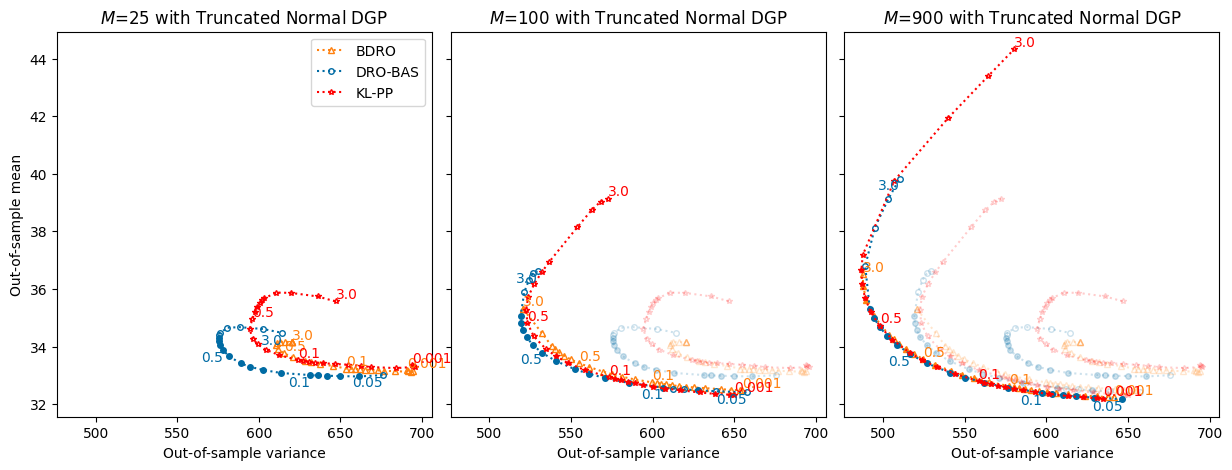

In [44]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)

for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            for k in range(j, len(total_samples_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend()
            axes[j].set_ylabel("Out-of-sample mean")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

# Plot sum of in-group variance and variance of in-group mean
Let $m$ be the number of test observations.
Let $k$ be the number of replications.
Let $\xi_{ij}$ be the $i^{\text{th}}$ test observation for replication $j$.
For a given replication $j$, the in-group mean and variance is
$$\mu_j = \frac{1}{m}\sum_{i=1}^m f(x_j, \xi_{ij}), \hspace{2em} v_j = \frac{1}{m-1}\sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \mu_j \right)^2$$

We define the mean across all replications and all test observations as
$$\bar{\mu} = \frac{1}{mk} \sum_{j=1}^k \sum_{i=1}^m f(x_j, \xi_{ij}).$$

The total variance is defined by $$\frac{1}{mk-1}\sum_{j=1}^k \sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \bar{\mu} \right)^2.$$
This can be decomposed into two terms.
The first is a constant times the sum of the in-group variances:
$$\frac{m-1}{km - 1} \sum^k_{j=1} v_j,$$
and the second term is a constant times the variance of the in-group means:
$$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j).$$


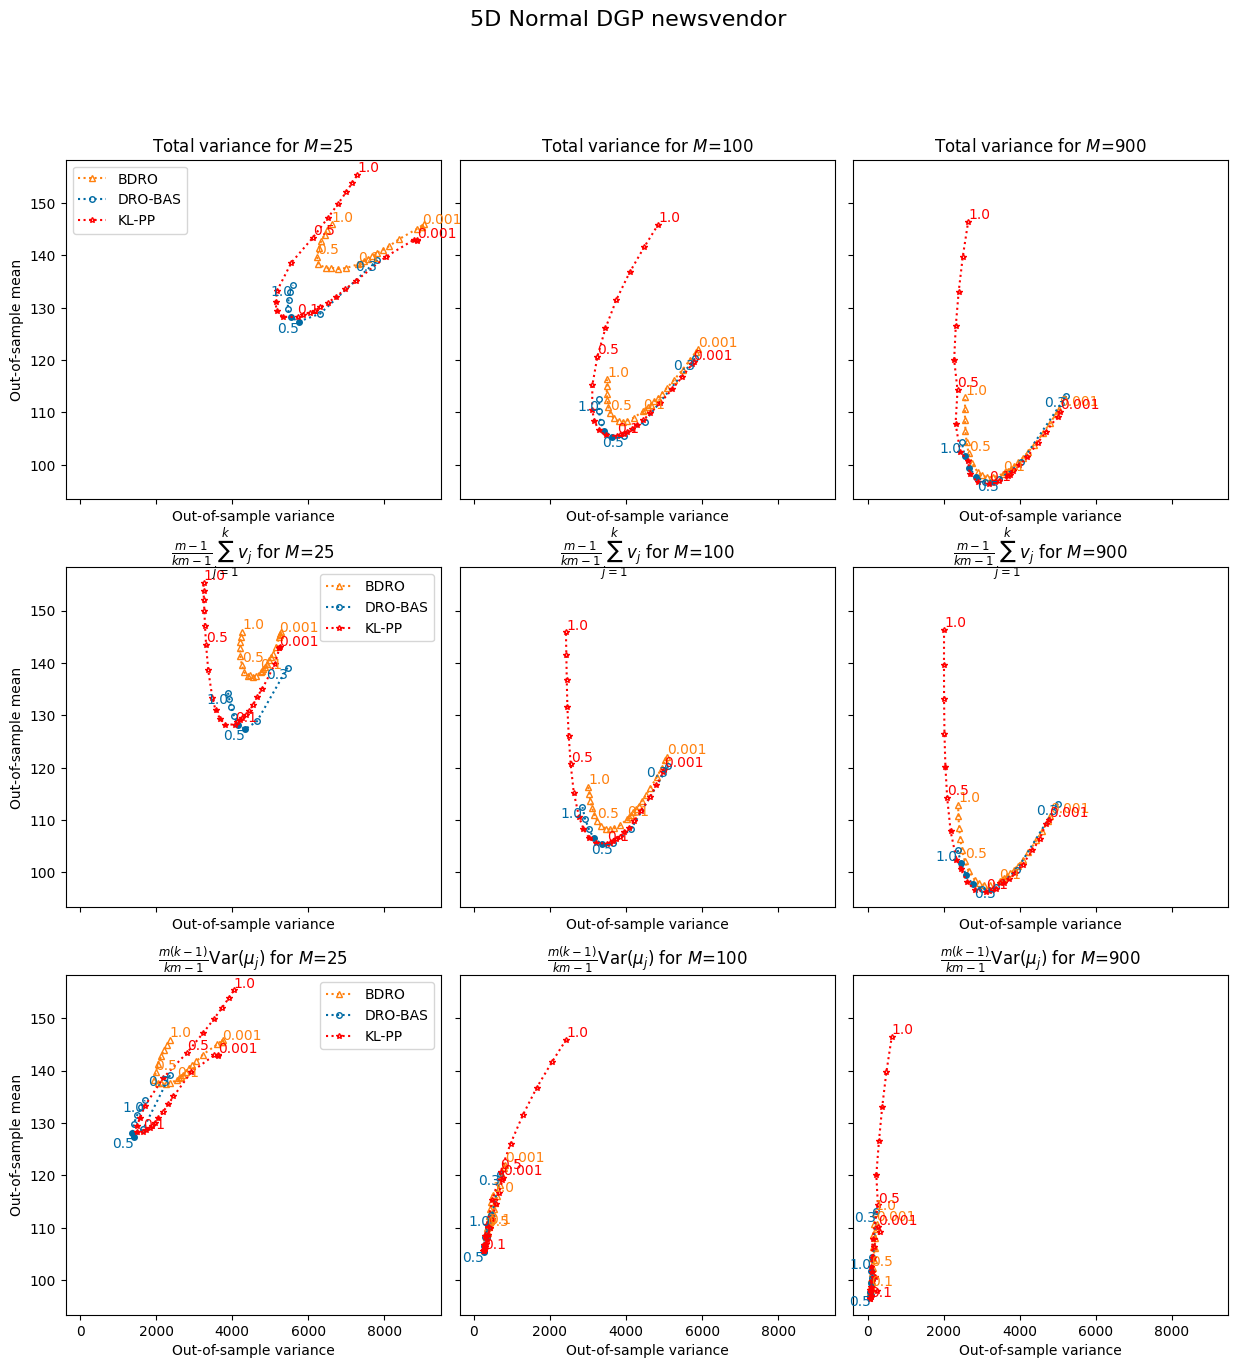

In [32]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[filter_dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_col in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :trim_epsilon, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_col)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_col] + " for $M$" + f"={total_samples}")
        axes[i][j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

## Solve & sampling time

In [33]:
solve_time_df = get_agg_df(results_df, ["algorithm", "num_total_samples"])
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())

\begin{tabular}{lllllll}
\toprule
 & \multicolumn{3}{r}{str_solve_time} & \multicolumn{3}{r}{str_sample_time} \\
algorithm & kl_bdro & kl_dro_bas & kl_pp & kl_bdro & kl_dro_bas & kl_pp \\
num_total_samples &  &  &  &  &  &  \\
\midrule
25 & 0.1018 (0.0113) & 0.0291 (0.0035) & 0.0296 (0.0036) & 0.0042 (0.0003) & 0.0004 (0.0) & 0.0004 (0.0) \\
100 & 0.2012 (0.0202) & 0.0761 (0.008) & 0.0777 (0.01) & 0.0077 (0.0003) & 0.0004 (0.0) & 0.0004 (0.0) \\
900 & 1.1515 (0.0678) & 0.9371 (0.0932) & 0.9553 (0.1024) & 0.0221 (0.0006) & 0.0005 (0.0) & 0.0006 (0.0) \\
\bottomrule
\end{tabular}



/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7efd18749a80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7efd18749bc0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


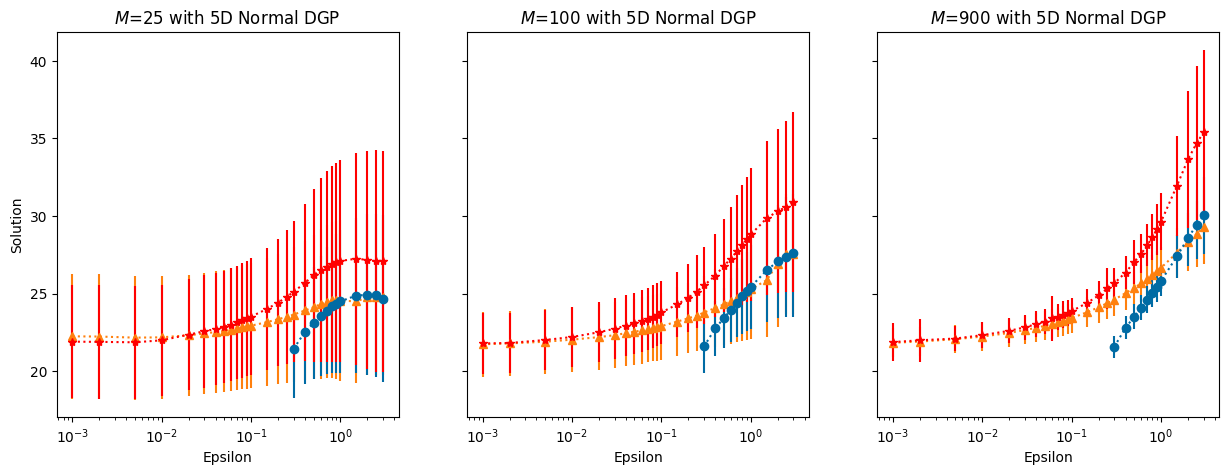

In [34]:
df = results_df.copy()
df["solution"] = df["solution"].map(lambda x: x[4])
nrows = len(dgp_list)
ncols = len(total_samples_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
solution_df = df.groupby(["algorithm", "dgp", "epsilon", "num_total_samples"]).agg({"solution": ["mean", "std"]})
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = solution_df.loc[:, dgp, :, total_samples]
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            axes[j].errorbar(axis_df.loc[algorithm, :].index.get_level_values("epsilon"), axis_df.loc[algorithm, :]["solution"]["mean"], yerr=axis_df.loc[algorithm, :]["solution"]["std"], **algorithm_inference_style(algorithm, "bayes"))
        axes[j].set_xscale("log")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Epsilon")
        if j == 0:
            axes[j].set_ylabel("Solution")

In [35]:
def get_num_likelihood_samples(num_total_samples: int, algorithm: str) -> int:
    if algorithm == "kl_bdro":
        return int(np.sqrt(num_total_samples))
    if algorithm in ("kl_dro_bas", "kl_pp"):
        return num_total_samples
    raise NotImplementedError()

def get_num_posterior_samples(num_total_samples: int, algorithm: str) -> int:
    if algorithm == "kl_bdro":
        return int(np.sqrt(num_total_samples))
    if algorithm in ("kl_dro_bas", "kl_pp"):
        return 1
    raise NotImplementedError()

In [36]:
get_num_posterior_samples(900, "kl_dro_bas")

1